# DATATHON 2026 — EDA: Customer Behavior Analytics for Profitable Growth



In [215]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns

DATA_DIR_CANDIDATES = [
    Path(r"D:\thao\d\datathon-2026-F.E.N.S\datathon-2026-round-1"),
    Path("/kaggle/input/datathon-2026-round-1"),

]

for candidate in DATA_DIR_CANDIDATES:
    if candidate.exists():
        DATA_DIR = candidate
        break
else:
    raise FileNotFoundError(
        "Khong tim thay thu muc dataset. Hay cap nhat DATA_DIR_CANDIDATES cho dung may cua ban."
    )

print(f"Using dataset from: {DATA_DIR}")


Using dataset from: D:\thao\d\datathon-2026-F.E.N.S\datathon-2026-round-1


In [216]:
TABLE_FILES = {
    "products": "products.csv",
    "customers": "customers.csv",
    "promotions": "promotions.csv",
    "geography": "geography.csv",
    "orders": "orders.csv",
    "order_items": "order_items.csv",
    "payments": "payments.csv",
    "shipments": "shipments.csv",
    "returns": "returns.csv",
    "reviews": "reviews.csv",
    "sales": "sales.csv",
    "sample_submission": "sample_submission.csv",
    "inventory": "inventory.csv",
    "web_traffic": "web_traffic.csv",
}

DATE_COLUMNS = {
    "customers": ["signup_date"],
    "promotions": ["start_date", "end_date"],
    "orders": ["order_date"],
    "shipments": ["ship_date", "delivery_date"],
    "returns": ["return_date"],
    "reviews": ["review_date"],
    "sales": ["Date"],
    "inventory": ["snapshot_date"],
    "web_traffic": ["date"],
}


def load_tables(data_dir, table_files, date_columns):
    tables = {}
    for table_name, file_name in table_files.items():
        tables[table_name] = pd.read_csv(
            data_dir / file_name,
            parse_dates=date_columns.get(table_name),
        )
    return tables


tables = load_tables(DATA_DIR, TABLE_FILES, DATE_COLUMNS)

products = tables["products"]
customers = tables["customers"]
promotions = tables["promotions"]
geography = tables["geography"]
orders = tables["orders"]
order_items = tables["order_items"]
payments = tables["payments"]
shipments = tables["shipments"]
returns = tables["returns"]
reviews = tables["reviews"]
sales = tables["sales"]
sample_sub = tables["sample_submission"]
inventory = tables["inventory"]
web_traffic = tables["web_traffic"]

print("=== DATASET OVERVIEW ===")
for table_name, table_df in tables.items():
    print(f"{table_name:20s} shape = {table_df.shape}")


C:\Users\Admin\AppData\Local\Temp\ipykernel_25532\2041488861.py:34: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  tables[table_name] = pd.read_csv(


=== DATASET OVERVIEW ===
products             shape = (2412, 8)
customers            shape = (121930, 7)
promotions           shape = (50, 10)
geography            shape = (39948, 4)
orders               shape = (646945, 8)
order_items          shape = (714669, 7)
payments             shape = (646945, 4)
shipments            shape = (566067, 4)
returns              shape = (39939, 7)
reviews              shape = (113551, 7)
sales                shape = (3833, 3)
sample_submission    shape = (548, 3)
inventory            shape = (60247, 17)
web_traffic          shape = (3652, 7)


## Helper Functions & Theme

- Mục tiêu: chuẩn hóa theme Datathon, helper formatting, và style biểu đồ để toàn bộ notebook nhìn thống nhất.



In [217]:
PALETTE = {
    "black": "#171717",
    "dark_gray": "#2B2B2B",
    "green": "#8CFF5A",
    "lime_green": "#A3FF6A",
    "white": "#FFFFFF",
    "light_gray": "#F2F4F3",
    "mid_gray": "#B8B8B8",
    "risk_red": "#FF5A5F",
    "warning": "#FFB020",
    "info_blue": "#4DA3FF",
    "base_bar": "#5A6472",
}

plt.rcParams.update(
    {
        "figure.facecolor": PALETTE["white"],
        "axes.facecolor": PALETTE["light_gray"],
        "axes.edgecolor": PALETTE["dark_gray"],
        "axes.labelcolor": PALETTE["black"],
        "axes.grid": True,
        "grid.color": PALETTE["mid_gray"],
        "grid.alpha": 0.4,
        "grid.linestyle": "--",
        "text.color": PALETTE["black"],
        "xtick.color": PALETTE["dark_gray"],
        "ytick.color": PALETTE["dark_gray"],
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 12,
        "legend.fontsize": 11,
    }
)
sns.set_theme(style="whitegrid")


def clean_axis(ax, xlabel: str = "", ylabel: str = "", title: str = "") -> None:
    if title:
        ax.set_title(title, fontsize=14, fontweight="bold", color=PALETTE["black"], pad=12)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=12, color=PALETTE["dark_gray"])
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=12, color=PALETTE["dark_gray"])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def add_bar_labels(ax, fmt="{:.1f}", unit: str = "", pct: bool = False, y_padding: float | None = None):
    heights = [patch.get_height() for patch in ax.patches if not np.isnan(patch.get_height())]
    if not heights:
        return
    offset = y_padding if y_padding is not None else max(heights) * 0.015
    for patch in ax.patches:
        value = patch.get_height()
        if np.isnan(value):
            continue
        label = f"{value:.1f}%" if pct else fmt.format(value)
        label += unit
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            value + offset,
            label,
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            color=PALETTE["dark_gray"],
        )


def add_hbar_labels(ax, fmt="{:.1f}", pct: bool = False):
    for patch in ax.patches:
        value = patch.get_width()
        if np.isnan(value):
            continue
        label = f"{value:.1f}%" if pct else fmt.format(value)
        ax.annotate(
            label,
            xy=(value, patch.get_y() + patch.get_height() / 2),
            xytext=(4, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=10,
            fontweight="bold",
            color=PALETTE["dark_gray"],
        )


def count_frame(series: pd.Series, label: str) -> pd.DataFrame:
    counts = series.fillna("Unknown").astype(str).value_counts()
    return counts.rename_axis(label).reset_index(name="count")


## Tổng quan nhanh về dữ liệu

Phần này tập trung vào các biểu đồ đếm cơ bản để nhìn nhanh cấu trúc dữ liệu trước khi đi vào phân tích sâu hơn.


#### Danh mục sản phẩm phân bố như thế nào?



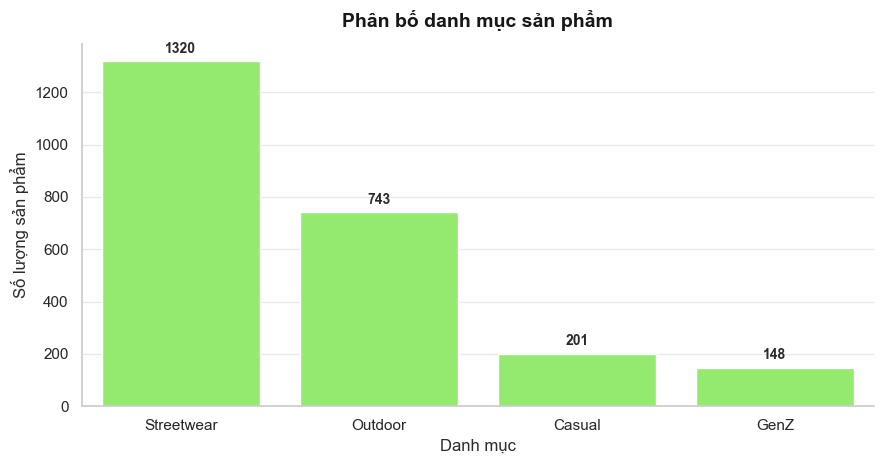

In [218]:
category_counts = count_frame(products["category"], "category")

fig, ax = plt.subplots(figsize=(9, 4.8))
sns.barplot(
    data=category_counts,
    x="category",
    y="count",
    color=PALETTE["green"],
    ax=ax,
)
clean_axis(ax, xlabel="Danh mục", ylabel="Số lượng sản phẩm", title="Phân bố danh mục sản phẩm")
ax.tick_params(axis="x")
add_bar_labels(ax, fmt="{:.0f}")
plt.tight_layout()
plt.show()


In [219]:
def plot_count_chart(
    df,
    column,
    title,
    xlabel,
    top_n=None,
    color_key="green",
    rotation=0,
    horizontal=False,
    figsize=None,
):
    plot_data = count_frame(df[column], column)
    if top_n is not None:
        plot_data = plot_data.head(top_n)

    if horizontal:
        fig, ax = plt.subplots(figsize=figsize or (10, 5.6))
        sns.barplot(
            data=plot_data,
            y=column,
            x="count",
            color=PALETTE[color_key],
            ax=ax,
        )
        clean_axis(ax, xlabel="Số lượng", ylabel=xlabel, title=title)
        add_hbar_labels(ax, fmt="{:.0f}")
    else:
        fig, ax = plt.subplots(figsize=figsize or (9, 4.8))
        sns.barplot(
            data=plot_data,
            x=column,
            y="count",
            color=PALETTE[color_key],
            ax=ax,
        )
        clean_axis(ax, xlabel=xlabel, ylabel="Số lượng", title=title)
        ax.tick_params(axis="x", rotation=rotation)
        add_bar_labels(ax, fmt="{:.0f}")

    plt.tight_layout()
    plt.show()


#### Segment sản phẩm phân bố như thế nào?


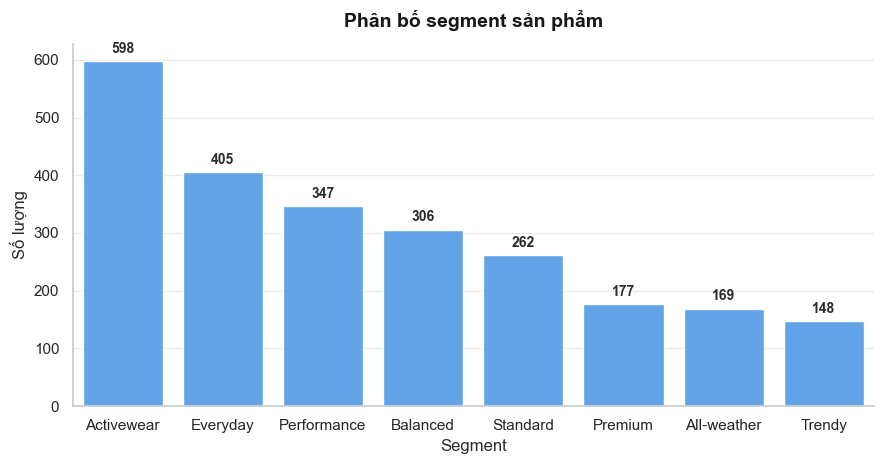

In [220]:
plot_count_chart(
    products,
    "segment",
    "Phân bố segment sản phẩm",
    "Segment",
    color_key="info_blue",
)


#### Khách hàng đến từ những thành phố nào?



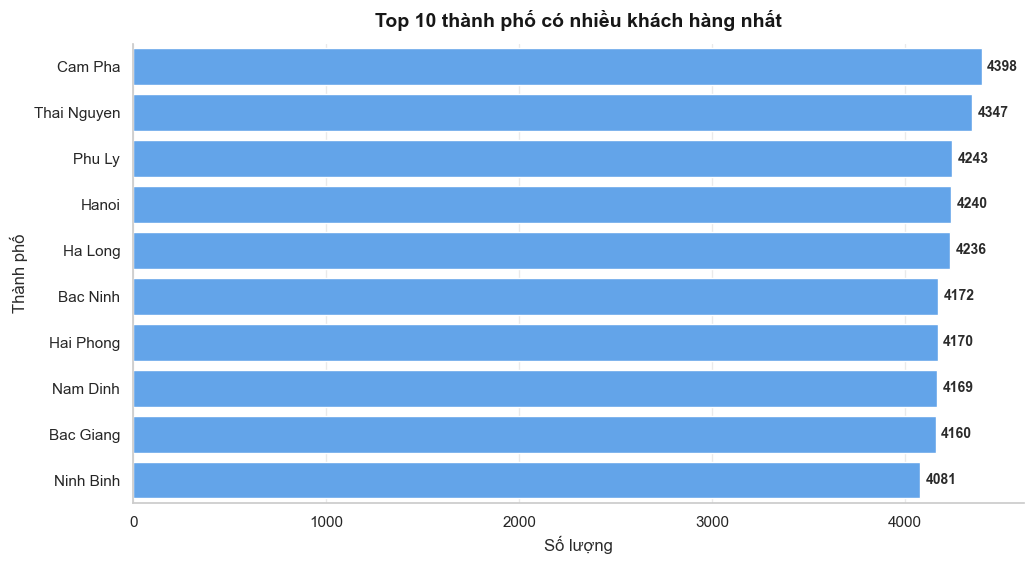

In [221]:
plot_count_chart(
    customers,
    "city",
    "Top 10 thành phố có nhiều khách hàng nhất",
    "Thành phố",
    top_n=10,
    color_key="info_blue",
    horizontal=True,
    figsize=(10.5, 5.8),
)


#### Giới tính của khách hàng phân bố ra sao?



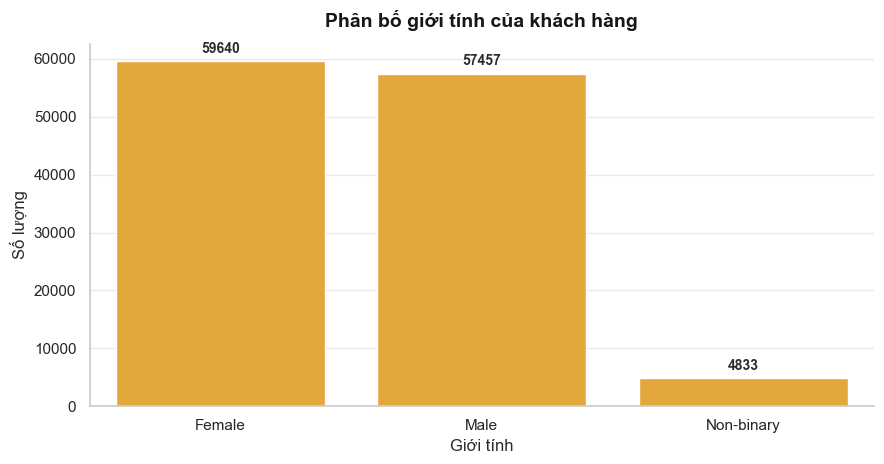

In [222]:
plot_count_chart(
    customers,
    "gender",
    "Phân bố giới tính của khách hàng",
    "Giới tính",
    color_key="warning",
)


#### Nhóm tuổi nào phổ biến hơn?


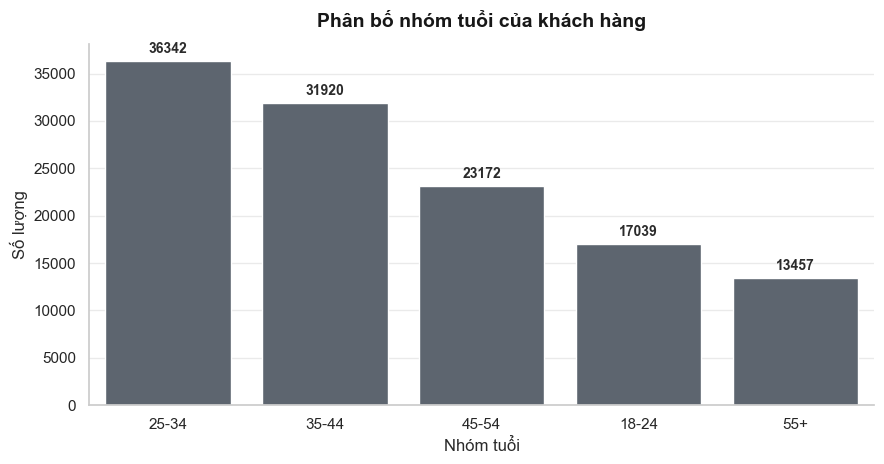

In [223]:
plot_count_chart(
    customers,
    "age_group",
    "Phân bố nhóm tuổi của khách hàng",
    "Nhóm tuổi",
    color_key="base_bar",
)


#### Trạng thái đơn hàng nào xuất hiện nhiều?


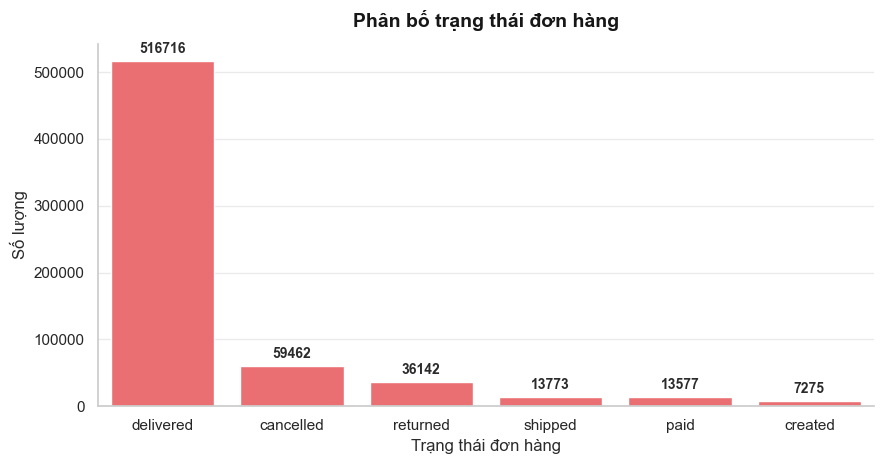

In [224]:
plot_count_chart(
    orders,
    "order_status",
    "Phân bố trạng thái đơn hàng",
    "Trạng thái đơn hàng",
    color_key="risk_red",
)


#### Phương thức thanh toán nào được ghi nhận?


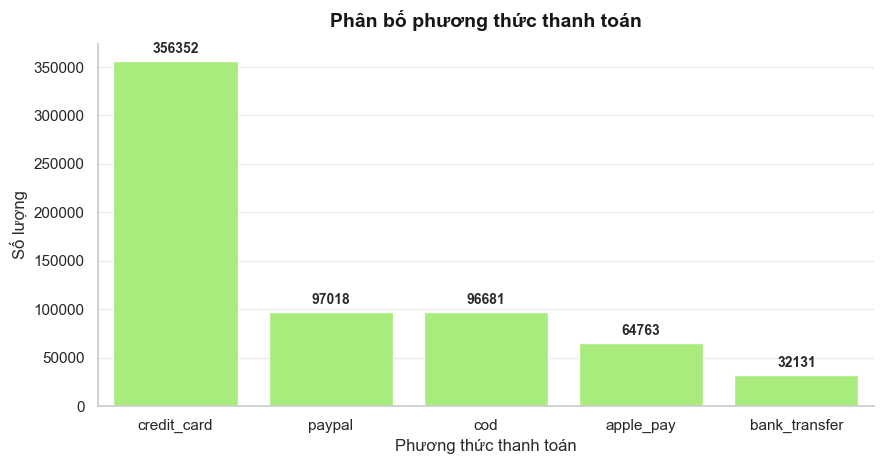

In [225]:
plot_count_chart(
    orders,
    "payment_method",
    "Phân bố phương thức thanh toán",
    "Phương thức thanh toán",
    color_key="lime_green",
)


#### Nguồn đơn hàng đến từ đâu?


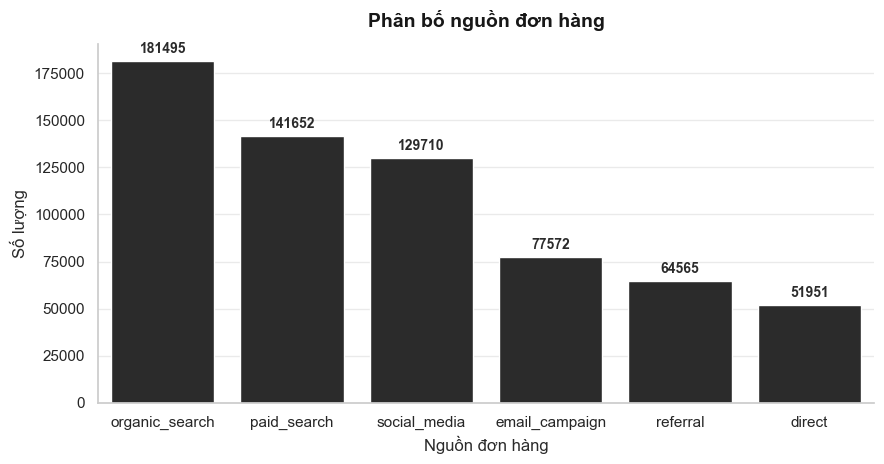

In [226]:
plot_count_chart(
    orders,
    "order_source",
    "Phân bố nguồn đơn hàng",
    "Nguồn đơn hàng",
    color_key="dark_gray",
)


#### Promotion mix nhìn nhanh ra sao?


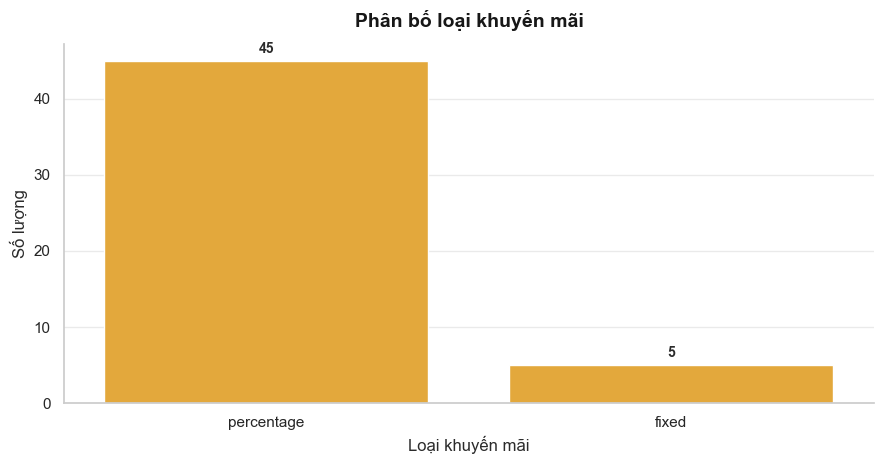

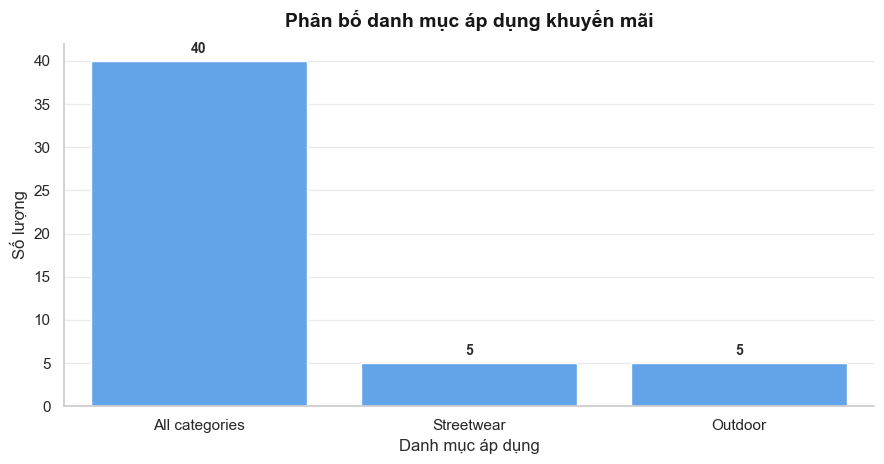

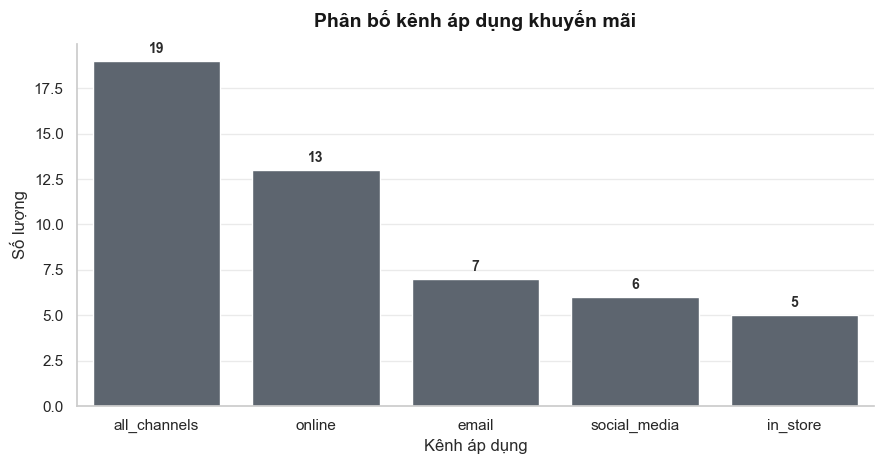

In [227]:
promotions_glance = promotions.assign(
    applicable_category_filled=promotions["applicable_category"].fillna("All categories"),
    promo_channel_filled=promotions["promo_channel"].fillna("Unknown")
)

plot_count_chart(
    promotions_glance,
    "promo_type",
    "Phân bố loại khuyến mãi",
    "Loại khuyến mãi",
    color_key="warning",
)

plot_count_chart(
    promotions_glance,
    "applicable_category_filled",
    "Phân bố danh mục áp dụng khuyến mãi",
    "Danh mục áp dụng",
    color_key="info_blue",
)

plot_count_chart(
    promotions_glance,
    "promo_channel_filled",
    "Phân bố kênh áp dụng khuyến mãi",
    "Kênh áp dụng",
    color_key="base_bar",
)


### Quick Insights

- Danh mục sản phẩm nghiêng mạnh về `Streetwear`, cho thấy đây nhiều khả năng là core identity của doanh nghiệp.
- Tệp khách hàng phân tán khá rộng theo thành phố; không có một địa bàn đơn lẻ nào chi phối toàn bộ customer base.
- Customer mix tập trung nhiều ở nhóm tuổi `25-44`, nên đây có thể là nhóm khách hàng lõi cho các phân tích tiếp theo về order value, product mix và retention.
- `Delivered` chiếm tỷ trọng lớn, nhưng `cancelled` và `returned` vẫn đủ đáng kể để có thể làm sai câu chuyện revenue nếu cộng toàn bộ order value vào KPI chính.
- `Credit card` là phương thức thanh toán chủ đạo và `organic_search`, `paid_search`, `social_media` là các nguồn đơn chính, cho thấy online acquisition là trục vận hành quan trọng.
- Promo setup chủ yếu là `percentage`, phần lớn áp dụng cho `All categories`, và kênh triển khai nghiêng nhiều về `all_channels` hoặc online. Điều này gợi ý doanh nghiệp dùng khuyến mãi theo kiểu broad-based campaign hơn là mechanic quá cá nhân hóa.

Từ các tín hiệu ban đầu này, bước hợp lý tiếp theo là kiểm tra lại một số giả định business quan trọng trước khi đi vào EDA hiệu quả kinh doanh.


## Data Quality Check

Mục tiêu của phần này không phải audit toàn bộ dataset, mà là khóa lại các assumption có thể làm sai KPI nếu hiểu nhầm:

1. `cancelled` có phải doanh thu thực hiện hay chỉ là order value đã được ghi nhận trong hệ thống?
2. Nhóm đơn `shipped`, `delivered`, `returned` có đủ bằng chứng vận hành để được xem là `realized orders` hay không?
3. Bảng `promotions` có đủ nhất quán để mình tin vào logic discount attribution hay không?
4. Bảng `inventory` có đủ nhất quán ở cấp snapshot để hỗ trợ diễn giải vận hành và seasonality hay không?


In [228]:
cancelled_orders = orders[
    orders["order_status"].str.lower().eq("cancelled")
].copy()

cancelled_payment_check = cancelled_orders.merge(
    payments[["order_id", "payment_value"]],
    on="order_id",
    how="left"
)

cancelled_payment_check["has_payment"] = cancelled_payment_check["payment_value"].notna()

cancelled_payment_summary = cancelled_payment_check.agg(
    cancelled_orders=("order_id", "nunique"),
    cancelled_orders_with_payment=("has_payment", "sum"),
    total_payment_value=("payment_value", "sum")
)

display(cancelled_payment_summary)

,order_id,has_payment,payment_value
cancelled_orders,59462.0,NaN,NaN
cancelled_orders_with_payment,NaN,59462.0,NaN
total_payment_value,NaN,NaN,1.447014e+09


In [229]:
cancelled_shipment_check = cancelled_orders.merge(
    shipments[["order_id", "ship_date", "delivery_date"]],
    on="order_id",
    how="left"
)

print("Cancelled orders:", cancelled_orders["order_id"].nunique())
print("Cancelled with shipment:", cancelled_shipment_check["ship_date"].notna().sum())
print("Cancelled with delivery:", cancelled_shipment_check["delivery_date"].notna().sum())

Cancelled orders: 59462
Cancelled with shipment: 0
Cancelled with delivery: 0


In [230]:
cancelled_return_check = cancelled_orders.merge(
    returns[["order_id", "refund_amount"]],
    on="order_id",
    how="left"
)

print("Cancelled with return/refund:", cancelled_return_check["refund_amount"].notna().sum())
print("Refund amount from cancelled:", cancelled_return_check["refund_amount"].sum())

Cancelled with return/refund: 0
Refund amount from cancelled: 0.0


#### Kết luận từ cancelled orders

`Cancelled` có payment record nhưng không có bằng chứng shipment, delivery hay return/refund đi kèm. Vì vậy trong phần business performance phía sau, nhóm này sẽ không được cộng vào `realized revenue`.

Nói cách khác, `payment_value` ở đây nên được hiểu gần với `recorded order value` hơn là `fulfilled revenue`.

### 2. Kiểm tra consistency giữa trạng thái đơn hàng và bảng vận hành

Sau khi tách `cancelled` khỏi revenue story, bước tiếp theo là xác nhận nhóm đơn nào thực sự có bằng chứng fulfillment. Logic kiểm tra là:

- `shipped`, `delivered`, `returned` nên có record trong `shipments`.
- `returned` nên tiếp tục có record trong `returns`.
- Nếu các quan hệ này nhìn chung nhất quán, nhóm order trên có thể được dùng làm `realized orders` cho phần business EDA.


In [231]:
shipment_status = ["shipped", "delivered", "returned"]

orders_check = orders.copy()
shipments_check = shipments.copy()
target_orders = orders_check.loc[
    orders_check["order_status"].isin(shipment_status), ["order_id", "order_status"]
]

shipment_order_ids = shipments_check[["order_id"]]

shipment_audit = target_orders.merge(
    shipment_order_ids.assign(has_shipment=True),
    on="order_id",
    how="left"
)

shipment_audit["has_shipment"] = shipment_audit["has_shipment"].fillna(False).astype(bool)

shipment_summary = (
    shipment_audit
    .groupby("order_status", as_index=False)
    .agg(
        total_orders=("order_id", "nunique"),
        orders_with_shipment=("has_shipment", "sum")
    )
)

shipment_summary["missing_shipment_orders"] = (
    shipment_summary["total_orders"] - shipment_summary["orders_with_shipment"]
)

shipment_summary["missing_shipment_rate"] = (
    shipment_summary["missing_shipment_orders"] / shipment_summary["total_orders"]
)

display(shipment_summary)

C:\Users\Admin\AppData\Local\Temp\ipykernel_25532\2846239148.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  shipment_audit["has_shipment"] = shipment_audit["has_shipment"].fillna(False).astype(bool)


,order_status,total_orders,orders_with_shipment,missing_shipment_orders,missing_shipment_rate
0,delivered,516716,516192,524,0.001014
1,returned,36142,36113,29,0.000802
2,shipped,13773,13762,11,0.000799


In [232]:
returned_orders = orders_check.loc[
    orders_check["order_status"].eq("returned"),
    ["order_id"]
]

return_order_ids = returns[["order_id"]].drop_duplicates()

return_audit = returned_orders.merge(
    return_order_ids.assign(has_return=True),
    on="order_id",
    how="left"
)

return_audit["has_return"] = return_audit["has_return"].fillna(False).astype(bool)

return_summary = pd.DataFrame({
    "metric": [
        "returned_orders",
        "returned_orders_with_return_record",
        "returned_orders_missing_return_record",
        "missing_return_rate"
    ],
    "value": [
        returned_orders["order_id"].nunique(),
        return_audit["has_return"].sum(),
        (~return_audit["has_return"]).sum(),
        (~return_audit["has_return"]).mean()
    ]
})

display(return_summary)

C:\Users\Admin\AppData\Local\Temp\ipykernel_25532\2087703638.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return_audit["has_return"] = return_audit["has_return"].fillna(False).astype(bool)


,metric,value
0,returned_orders,36142.000000
1,returned_orders_with_return_record,36062.000000
2,returned_orders_missing_return_record,80.000000
3,missing_return_rate,0.002213


### 3. Kiểm tra logic promotion và discount attribution

`Discount amount` là một biến rất quan trọng trong phần revenue, gross profit và margin pressure. Vì vậy trước khi dùng nó cho EDA, cần xác nhận 3 điểm:

- `promo_id` và `promo_id_2` có map được về bảng `promotions` hay không.
- Order có đang dùng promo trong đúng thời gian hiệu lực hay không.
- Có row nào áp dụng đồng thời 2 promo dù campaign được đánh dấu `non-stackable` hay không.


In [233]:
promo_ref_1 = promotions.add_prefix("promo_").rename(columns={"promo_promo_id": "promo_id"})
promo_ref_2 = promotions.add_prefix("promo2_").rename(columns={"promo2_promo_id": "promo_id_2"})

promo_check = order_items.merge(
    orders[["order_id", "order_date"]],
    on="order_id",
    how="left"
)
promo_check = promo_check.merge(promo_ref_1, on="promo_id", how="left")
promo_check = promo_check.merge(promo_ref_2, on="promo_id_2", how="left")

promo_check["has_promo_1"] = promo_check["promo_id"].notna()
promo_check["has_promo_2"] = promo_check["promo_id_2"].notna()
promo_check["has_any_promo"] = promo_check["has_promo_1"] | promo_check["has_promo_2"]
promo_check["has_two_promos"] = promo_check["has_promo_1"] & promo_check["has_promo_2"]

promo_check["invalid_promo_1_ref"] = promo_check["has_promo_1"] & promo_check["promo_promo_name"].isna()
promo_check["invalid_promo_2_ref"] = promo_check["has_promo_2"] & promo_check["promo2_promo_name"].isna()

promo_check["promo_1_outside_window"] = (
    promo_check["has_promo_1"]
    & ~promo_check["invalid_promo_1_ref"]
    & ~promo_check["order_date"].between(promo_check["promo_start_date"], promo_check["promo_end_date"])
)
promo_check["promo_2_outside_window"] = (
    promo_check["has_promo_2"]
    & ~promo_check["invalid_promo_2_ref"]
    & ~promo_check["order_date"].between(promo_check["promo2_start_date"], promo_check["promo2_end_date"])
)

promo_check["has_non_stackable_conflict"] = (
    promo_check["has_two_promos"]
    & (
        promo_check["promo_stackable_flag"].eq(0)
        | promo_check["promo2_stackable_flag"].eq(0)
    )
)

promotion_quality_summary = pd.DataFrame({
    "metric": [
        "order_item_rows_with_any_promo",
        "order_item_rows_with_two_promos",
        "invalid_promo_1_refs",
        "invalid_promo_2_refs",
        "promo_usage_outside_window_rows",
        "non_stackable_rows_with_two_promos"
    ],
    "value": [
        promo_check["has_any_promo"].sum(),
        promo_check["has_two_promos"].sum(),
        promo_check["invalid_promo_1_ref"].sum(),
        promo_check["invalid_promo_2_ref"].sum(),
        (promo_check["promo_1_outside_window"] | promo_check["promo_2_outside_window"]).sum(),
        promo_check["has_non_stackable_conflict"].sum()
    ]
})

promo_usage_long = pd.concat([
    promo_check.loc[promo_check["has_promo_1"], ["promo_id"]],
    promo_check.loc[promo_check["has_promo_2"], ["promo_id_2"]].rename(columns={"promo_id_2": "promo_id"})
], ignore_index=True)

top_used_promotions = (
    promo_usage_long.groupby("promo_id", as_index=False)
    .size()
    .rename(columns={"size": "promo_usage_rows"})
    .merge(
        promotions[["promo_id", "promo_name", "promo_type", "promo_channel", "stackable_flag"]],
        on="promo_id",
        how="left"
    )
    .sort_values("promo_usage_rows", ascending=False)
    .head(10)
)

display(promotion_quality_summary)
display(top_used_promotions)


,metric,value
0,order_item_rows_with_any_promo,276316
1,order_item_rows_with_two_promos,206
2,invalid_promo_1_refs,0
3,invalid_promo_2_refs,0
4,promo_usage_outside_window_rows,0
5,non_stackable_rows_with_two_promos,206


,promo_id,promo_usage_rows,promo_name,promo_type,promo_channel,stackable_flag
13,PROMO-0014,11451,Year-End Sale 2015,percentage,all_channels,1
9,PROMO-0010,11345,Year-End Sale 2014,percentage,all_channels,0
3,PROMO-0004,11126,Year-End Sale 2013,percentage,all_channels,0
19,PROMO-0020,10121,Year-End Sale 2016,percentage,all_channels,0
10,PROMO-0011,9594,Spring Sale 2015,percentage,all_channels,1
6,PROMO-0007,9373,Spring Sale 2014,percentage,email,1
20,PROMO-0021,8966,Spring Sale 2017,percentage,all_channels,0
16,PROMO-0017,8808,Spring Sale 2016,percentage,all_channels,0
0,PROMO-0001,8523,Spring Sale 2013,percentage,email,1
23,PROMO-0024,8205,Year-End Sale 2017,percentage,all_channels,0


#### Insight từ promotion sanity check

Mapping giữa `order_items` và `promotions` nhìn chung sạch ở mức tham chiếu và thời gian hiệu lực: promo được dùng đúng campaign window và không có promo id lạ.

Tuy nhiên vẫn có một nhóm nhỏ row áp dụng đồng thời 2 promo dù campaign liên quan được đánh dấu `non-stackable`. Vì vậy trong phần EDA, `discount_amount` vẫn có thể dùng để đọc aggregate discount pressure, nhưng cần thận trọng nếu diễn giải quá chặt ở cấp rule-engine của từng chiến dịch.


### 4. Kiểm tra logic snapshot của inventory

`Inventory` là ảnh chụp cuối tháng, nên cần kiểm tra bằng logic vận hành thay vì chỉ nhìn mô tả cột.

- Rule cân bằng tồn kho chỉ áp dụng khi cùng một SKU có snapshot liền tháng.
- Nếu giữa hai snapshot bị khuyết tháng, không dùng row trước đó để kết luận balance issue.
- `stockout_days > 0` không tự động là anomaly, vì SKU có thể stockout trong tháng rồi được nhập bù trước ngày snapshot.

Vì vậy ở đây chỉ kiểm tra các mâu thuẫn logic rõ ràng như balance trên snapshot liền tháng, flag, range và month-end snapshot.


In [234]:
inventory_check = inventory.copy()
inventory_check = inventory_check.sort_values(["product_id", "snapshot_date"])

inventory_check["prev_snapshot_date"] = (
    inventory_check
    .groupby("product_id")["snapshot_date"]
    .shift(1)
)
inventory_check["prev_stock_on_hand"] = (
    inventory_check
    .groupby("product_id")["stock_on_hand"]
    .shift(1)
)
inventory_check["month_gap"] = (
    (inventory_check["snapshot_date"].dt.year - inventory_check["prev_snapshot_date"].dt.year) * 12
    + (inventory_check["snapshot_date"].dt.month - inventory_check["prev_snapshot_date"].dt.month)
)
inventory_check["has_contiguous_prev"] = (
    inventory_check["prev_snapshot_date"].notna()
    & inventory_check["month_gap"].eq(1)
)

inventory_check["expected_stock_on_hand"] = (
    inventory_check["prev_stock_on_hand"]
    + inventory_check["units_received"]
    - inventory_check["units_sold"]
)

inventory_check["stock_diff"] = (
    inventory_check["stock_on_hand"] - inventory_check["expected_stock_on_hand"]
)

inventory_check["has_stock_balance_issue"] = (
    inventory_check["has_contiguous_prev"]
    & inventory_check["stock_diff"].ne(0)
)

inventory_balance_summary = pd.DataFrame({
    "metric": [
        "inventory_rows_checked",
        "rows_with_previous_snapshot",
        "rows_with_contiguous_previous_snapshot",
        "rows_skipped_due_to_snapshot_gap",
        "rows_with_stock_balance_issue",
        "stock_balance_issue_rate_on_contiguous_rows",
        "avg_abs_stock_diff_on_contiguous_rows",
        "max_abs_stock_diff_on_contiguous_rows"
    ],
    "value": [
        len(inventory_check),
        inventory_check["prev_snapshot_date"].notna().sum(),
        inventory_check["has_contiguous_prev"].sum(),
        (inventory_check["prev_snapshot_date"].notna() & ~inventory_check["has_contiguous_prev"]).sum(),
        inventory_check["has_stock_balance_issue"].sum(),
        inventory_check.loc[inventory_check["has_contiguous_prev"], "has_stock_balance_issue"].mean(),
        inventory_check.loc[inventory_check["has_contiguous_prev"], "stock_diff"].abs().mean(),
        inventory_check.loc[inventory_check["has_contiguous_prev"], "stock_diff"].abs().max()
    ]
})

display(inventory_balance_summary)

,metric,value
0,inventory_rows_checked,60247.0
1,rows_with_previous_snapshot,58623.0
2,rows_with_contiguous_previous_snapshot,51524.0
3,rows_skipped_due_to_snapshot_gap,7099.0
4,rows_with_stock_balance_issue,0.0
5,stock_balance_issue_rate_on_contiguous_rows,0.0
6,avg_abs_stock_diff_on_contiguous_rows,0.0
7,max_abs_stock_diff_on_contiguous_rows,0.0


In [235]:
inventory_check["has_stockout_flag_issue"] = (
    ((inventory_check["stockout_days"] > 0) & inventory_check["stockout_flag"].eq(0))
    | ((inventory_check["stockout_days"] == 0) & inventory_check["stockout_flag"].eq(1))
)
inventory_check["has_invalid_rate"] = (
    ~inventory_check["fill_rate"].between(0, 1)
    | ~inventory_check["sell_through_rate"].between(0, 1)
)
inventory_check["has_negative_metric"] = (
    inventory_check[["stock_on_hand", "units_received", "units_sold", "stockout_days", "days_of_supply"]]
    .lt(0)
    .any(axis=1)
)
inventory_check["not_month_end_snapshot"] = ~inventory_check["snapshot_date"].dt.is_month_end

inventory_sanity_summary = pd.DataFrame({
    "metric": [
        "rows_with_stockout_flag_issue",
        "rows_with_invalid_rate",
        "rows_with_negative_metric",
        "rows_with_non_month_end_snapshot"
    ],
    "value": [
        inventory_check["has_stockout_flag_issue"].sum(),
        inventory_check["has_invalid_rate"].sum(),
        inventory_check["has_negative_metric"].sum(),
        inventory_check["not_month_end_snapshot"].sum()
    ]
})

display(inventory_sanity_summary)

display(
    inventory_check[
        inventory_check["has_stockout_flag_issue"]
        | inventory_check["has_invalid_rate"]
        | inventory_check["has_negative_metric"]
        | inventory_check["not_month_end_snapshot"]
    ][
        [
            "snapshot_date",
            "product_id",
            "product_name",
            "category",
            "stock_on_hand",
            "units_received",
            "units_sold",
            "stockout_days",
            "stockout_flag",
            "days_of_supply",
            "fill_rate",
            "sell_through_rate",
            "has_stockout_flag_issue",
            "has_invalid_rate",
            "has_negative_metric",
            "not_month_end_snapshot"
        ]
    ]
    .sort_values(["snapshot_date", "product_id"])
    .head(30)
)

,metric,value
0,rows_with_stockout_flag_issue,0
1,rows_with_invalid_rate,0
2,rows_with_negative_metric,0
3,rows_with_non_month_end_snapshot,0


,snapshot_date,product_id,product_name,category,stock_on_hand,units_received,units_sold,stockout_days,stockout_flag,days_of_supply,fill_rate,sell_through_rate,has_stockout_flag_issue,has_invalid_rate,has_negative_metric,not_month_end_snapshot


#### Data Quality Conclusion

- `Cancelled` có payment record nhưng không có dấu hiệu fulfillment, nên sẽ bị loại khỏi revenue thực hiện.
- Nhóm `shipped`, `delivered`, `returned` nhìn chung nhất quán với bảng vận hành, nên có thể dùng làm `realized orders` cho business performance.
- Promotion reference và campaign window nhìn chung sạch, nhưng vẫn có một nhóm nhỏ row stack 2 promo dù rule ghi `non-stackable`; vì vậy nên tin `discount_amount` ở aggregate level hơn là giả định rule engine tuyệt đối sạch ở từng row.
- Inventory snapshot đủ nhất quán để đọc vận hành, nhưng balance rule chỉ nên áp dụng trên snapshot liền tháng.

Với các assumption này đã được khóa lại, phần EDA phía dưới có thể tập trung vào growth, profitability và seasonality mà không bị lẫn giữa `recorded order value` và `realized business performance`.


# EDA

Sau khi overview nhanh và data quality check đã khóa lại order universe, lớp 1 bên dưới tập trung vào `money flow` của doanh nghiệp trong giai đoạn `2012-07-04 -> 2022-12-31`.

Mục tiêu của lớp này là để người xem nhìn vào là hiểu ngay tiền đi theo luồng nào: vào bao nhiêu, hụt ở đâu, còn giữ lại được bao nhiêu và thời điểm nào biến động mạnh nhất.


## Business Overview: Lớp 1 - Dòng tiền doanh nghiệp 2012-2022

- Phần này đọc `commercial money flow` theo logic đơn hàng, không phải báo cáo lưu chuyển tiền tệ kế toán đầy đủ.
- Order universe chính là `delivered`, `shipped`, `returned` để tránh cộng nhầm `cancelled` vào tiền thực hiện.
- Money flow cốt lõi được đọc theo chuỗi: `Gross Sales -> Discount -> Net Revenue -> COGS -> Gross Profit`.
- `Cancelled order value` và `refund_amount` được tách riêng như các dòng tiền bị rò rỉ hoặc bị kéo ngược lại.
- Mục tiêu là nhìn thật trực diện: tiền vào bao nhiêu, hao hụt ở khâu nào, giữ lại được bao nhiêu và biến động ra sao qua từng năm.


### 1. Chuẩn bị business metrics

- Bước này biến `orders + order_items + products` thành `order_fact` ở grain `1 dòng = 1 SKU trong 1 realized order`.
- Từ `order_fact`, dữ liệu được aggregate lên tháng và năm để đọc cùng một money-flow logic xuyên suốt từ đầu tới cuối notebook.
- Phần dưới sẽ ưu tiên biểu đồ cấp năm trước để người xem nắm được bức tranh 11 năm ngay, sau đó mới đi xuống seasonality và biến động theo tháng.


In [236]:
realized_status = ['delivered', 'shipped', 'returned']

orders_eda = orders[orders['order_status'].isin(realized_status)].copy()
order_items_eda = order_items.copy()
products_eda = products.copy()

cancelled_order_count = cancelled_orders['order_id'].nunique()
cancelled_order_value = cancelled_payment_check['payment_value'].sum()

product_cols = ['product_id', 'category', 'segment', 'price', 'cogs']
order_fact = orders_eda.merge(order_items_eda, on='order_id', how='inner')
order_fact = order_fact.merge(products_eda[product_cols], on='product_id', how='left')
order_fact = order_fact.rename(columns={'cogs': 'product_unit_cogs'})

order_fact['gross_line_sales'] = order_fact['quantity'] * order_fact['unit_price']
order_fact['line_revenue'] = order_fact['gross_line_sales'] - order_fact['discount_amount']
order_fact['discount_rate'] = order_fact['discount_amount'] / order_fact['gross_line_sales'].replace(0, np.nan)
order_fact['line_cogs'] = order_fact['quantity'] * order_fact['product_unit_cogs']
order_fact['line_gross_profit'] = order_fact['line_revenue'] - order_fact['line_cogs']
order_fact['line_gross_margin'] = order_fact['line_gross_profit'] / order_fact['line_revenue'].replace(0, np.nan)

order_fact['year'] = order_fact['order_date'].dt.year
order_fact['month'] = order_fact['order_date'].dt.month
order_fact['month_name'] = order_fact['order_date'].dt.strftime('%b')
order_fact['year_month'] = order_fact['order_date'].dt.to_period('M').dt.to_timestamp()


def aggregate_business(frame: pd.DataFrame, group_key: str) -> pd.DataFrame:
    return (
        frame.groupby(group_key, as_index=False)
        .agg(
            revenue=('line_revenue', 'sum'),
            gross_line_sales=('gross_line_sales', 'sum'),
            discount_amount=('discount_amount', 'sum'),
            cogs=('line_cogs', 'sum'),
            gross_profit=('line_gross_profit', 'sum'),
            order_count=('order_id', pd.Series.nunique),
            customer_count=('customer_id', pd.Series.nunique),
            total_quantity=('quantity', 'sum'),
        )
    )


def add_business_ratios(df: pd.DataFrame, growth_prefix: str) -> pd.DataFrame:
    df = df.copy()
    df['gross_margin'] = df['gross_profit'] / df['revenue'].replace(0, np.nan)
    df['discount_rate'] = df['discount_amount'] / df['gross_line_sales'].replace(0, np.nan)
    df['aov'] = df['revenue'] / df['order_count'].replace(0, np.nan)
    df['units_per_order'] = df['total_quantity'] / df['order_count'].replace(0, np.nan)
    df['revenue_per_unit'] = df['revenue'] / df['total_quantity'].replace(0, np.nan)
    df[f'{growth_prefix}_revenue_growth'] = df['revenue'].pct_change()
    df[f'{growth_prefix}_gross_profit_growth'] = df['gross_profit'].pct_change()
    df['margin_change'] = df['gross_margin'].diff()
    return df


monthly_business = aggregate_business(order_fact, 'year_month').sort_values('year_month').reset_index(drop=True)
monthly_business = add_business_ratios(monthly_business, 'mom')
monthly_business['year'] = monthly_business['year_month'].dt.year
monthly_business['month'] = monthly_business['year_month'].dt.month
monthly_business['month_name'] = monthly_business['year_month'].dt.strftime('%b')
monthly_business['month_label'] = 'T' + monthly_business['month'].astype(str)
monthly_business['cumulative_revenue'] = monthly_business['revenue'].cumsum()
monthly_business['cumulative_gross_profit'] = monthly_business['gross_profit'].cumsum()

yearly_business = aggregate_business(order_fact, 'year').sort_values('year').reset_index(drop=True)
yearly_business = add_business_ratios(yearly_business, 'yoy')

calendar_month_profile = (
    monthly_business.groupby(['month', 'month_name'], as_index=False)
    .agg(
        avg_revenue=('revenue', 'mean'),
        avg_gross_margin=('gross_margin', 'mean'),
    )
    .sort_values('month')
)
calendar_month_profile['month_label'] = 'T' + calendar_month_profile['month'].astype(str)

margin_pressure_months = monthly_business.loc[
    (monthly_business['mom_revenue_growth'] > 0) & (monthly_business['margin_change'] < 0)
].copy()
margin_pressure_months = margin_pressure_months.sort_values(
    ['mom_revenue_growth', 'margin_change'], ascending=[False, True]
).reset_index(drop=True)

peak_month_by_year = monthly_business.loc[
    monthly_business.groupby('year')['revenue'].idxmax(),
    ['year', 'month', 'month_label', 'revenue'],
].sort_values('year')

analysis_start = orders_eda['order_date'].min()
analysis_end = orders_eda['order_date'].max()
analysis_years = yearly_business['year'].nunique()

overall_money_bridge = pd.DataFrame(
    {
        'stage': ['Gross Sales', 'Discount', 'Net Revenue', 'COGS', 'Gross Profit'],
        'value': [
            order_fact['gross_line_sales'].sum(),
            -order_fact['discount_amount'].sum(),
            order_fact['line_revenue'].sum(),
            -order_fact['line_cogs'].sum(),
            order_fact['line_gross_profit'].sum(),
        ],
        'bar_type': ['total', 'delta', 'total', 'delta', 'total'],
    }
)


def format_currency(value):
    return 'N/A' if pd.isna(value) else f'{value:,.0f}'


def format_number(value):
    return 'N/A' if pd.isna(value) else f'{value:,.0f}'


def format_pct(value):
    return 'N/A' if pd.isna(value) else f'{value:.2%}'


def format_period(value):
    return 'N/A' if pd.isna(value) else pd.to_datetime(value).strftime('%Y-%m')


def format_billions(value):
    return 'N/A' if pd.isna(value) else f'{value / 1e9:.2f}B'


def axis_billions(x, pos):
    return f'{x / 1e9:.1f}B'


def axis_millions(x, pos):
    return f'{x / 1e6:.0f}M'


### 2. KPI Snapshot

Bảng snapshot dưới đây dùng cùng order universe đã được khóa ở bước data quality: `delivered`, `shipped`, `returned`. `Cancelled` được giữ riêng như một proxy của cancelled order value, không cộng vào revenue thực hiện.


In [237]:
best_revenue_year_row = yearly_business.loc[yearly_business["revenue"].idxmax()]
best_revenue_month_row = monthly_business.loc[monthly_business["revenue"].idxmax()]

kpi_snapshot = pd.DataFrame(
    {
        "KPI": [
            "Total Revenue",
            "Total COGS",
            "Total Gross Profit",
            "Overall Gross Margin",
            "Realized Orders",
            "Realized Customers",
            "Total Units Sold",
            "Average Order Value",
            "Average Units per Order",
            "First Realized Order Date",
            "Last Realized Order Date",
            "Cancelled Orders (Excluded)",
            "Cancelled Order Value (Proxy)",
            "Best Revenue Year",
            "Best Revenue Month",
        ],
        "Giá trị": [
            format_currency(monthly_business["revenue"].sum()),
            format_currency(monthly_business["cogs"].sum()),
            format_currency(monthly_business["gross_profit"].sum()),
            format_pct(monthly_business["gross_profit"].sum() / monthly_business["revenue"].sum()),
            format_number(orders_eda["order_id"].nunique()),
            format_number(order_fact["customer_id"].nunique()),
            format_number(order_fact["quantity"].sum()),
            format_currency(monthly_business["revenue"].sum() / orders_eda["order_id"].nunique()),
            f"{order_fact['quantity'].sum() / orders_eda['order_id'].nunique():.2f}",
            orders_eda["order_date"].min().strftime("%Y-%m-%d"),
            orders_eda["order_date"].max().strftime("%Y-%m-%d"),
            format_number(cancelled_order_count),
            format_currency(cancelled_order_value),
            f"{int(best_revenue_year_row['year'])} ({format_currency(best_revenue_year_row['revenue'])})",
            f"{format_period(best_revenue_month_row['year_month'])} ({format_currency(best_revenue_month_row['revenue'])})",
        ],
    }
)

display(kpi_snapshot)


,KPI,Giá trị
0,Total Revenue,"13,721,393,513"
1,Total COGS,"12,392,176,655"
2,Total Gross Profit,"1,329,216,858"
3,Overall Gross Margin,9.69%
4,Realized Orders,"566,631"
5,Realized Customers,"87,280"
6,Total Units Sold,"2,813,568"
7,Average Order Value,"24,216"
8,Average Units per Order,4.97
9,First Realized Order Date,2012-07-04


### 3. Bức tranh dòng tiền gộp của cả giai đoạn nhìn nhanh ra sao?

Biểu đồ đầu tiên phải trả lời ngay một câu hỏi: từ toàn bộ giá trị bán ra, doanh nghiệp bị trừ bao nhiêu ở discount, tốn bao nhiêu ở COGS và cuối cùng còn giữ lại bao nhiêu gross profit.


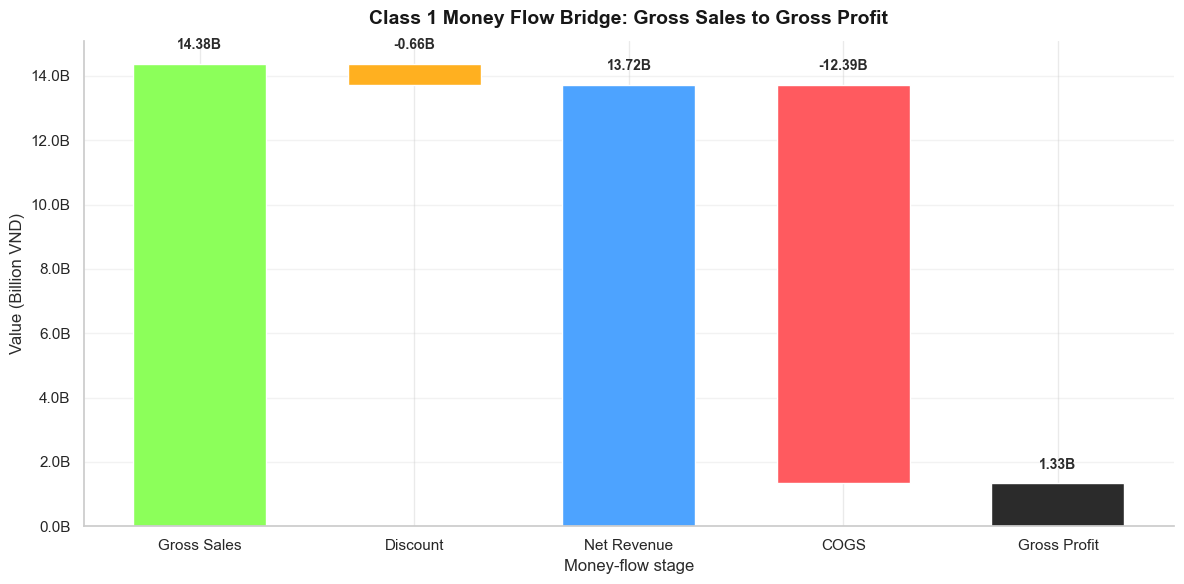

Khoảng thời gian phân tích: 2012-07-04 -> 2022-12-31
Số năm dữ liệu realized orders: 11
Gross sales: 14,378,010,394
Discount deducted: 656,616,881
Net revenue: 13,721,393,513
COGS consumed: 12,392,176,655
Gross profit retained: 1,329,216,858
Cancelled order value (proxy, excluded from revenue): 1,447,013,637


In [238]:
bridge_plot = overall_money_bridge.copy()
bridge_plot['bottom'] = 0.0
bridge_plot['height'] = 0.0
bridge_plot['label_y'] = 0.0

running_total = 0.0
for idx, row in bridge_plot.iterrows():
    value = row['value']
    if row['bar_type'] == 'total':
        bottom = 0.0
        height = value
        running_total = value
    else:
        next_total = running_total + value
        bottom = min(running_total, next_total)
        height = abs(value)
        running_total = next_total
    bridge_plot.loc[idx, 'bottom'] = bottom
    bridge_plot.loc[idx, 'height'] = height
    bridge_plot.loc[idx, 'label_y'] = bottom + height

bridge_colors = [
    PALETTE['green'],
    PALETTE['warning'],
    PALETTE['info_blue'],
    PALETTE['risk_red'],
    PALETTE['dark_gray'],
]

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(
    bridge_plot['stage'],
    bridge_plot['height'],
    bottom=bridge_plot['bottom'],
    color=bridge_colors,
    width=0.62,
)

for idx, row in bridge_plot.iterrows():
    ax.text(
        idx,
        row['label_y'] + overall_money_bridge['value'].abs().max() * 0.025,
        format_billions(row['value']),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color=PALETTE['dark_gray'],
    )

clean_axis(
    ax,
    xlabel='Money-flow stage',
    ylabel='Value (Billion VND)',
    title='Class 1 Money Flow Bridge: Gross Sales to Gross Profit',
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(axis_billions))
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

print('Khoảng thời gian phân tích:', analysis_start.strftime('%Y-%m-%d'), '->', analysis_end.strftime('%Y-%m-%d'))
print('Số năm dữ liệu realized orders:', analysis_years)
print('Gross sales:', format_currency(order_fact['gross_line_sales'].sum()))
print('Discount deducted:', format_currency(order_fact['discount_amount'].sum()))
print('Net revenue:', format_currency(order_fact['line_revenue'].sum()))
print('COGS consumed:', format_currency(order_fact['line_cogs'].sum()))
print('Gross profit retained:', format_currency(order_fact['line_gross_profit'].sum()))
print('Cancelled order value (proxy, excluded from revenue):', format_currency(cancelled_order_value))


### 4. Mỗi năm revenue được chia thành cost và profit ra sao?

Đây là biểu đồ chính của lớp 1 ở cấp năm: mỗi cột là toàn bộ revenue của một năm, trong đó phần đáy là COGS và phần nằm trên là gross profit còn giữ lại. Đường line đi kèm cho biết biên lợi nhuận gộp của từng năm.


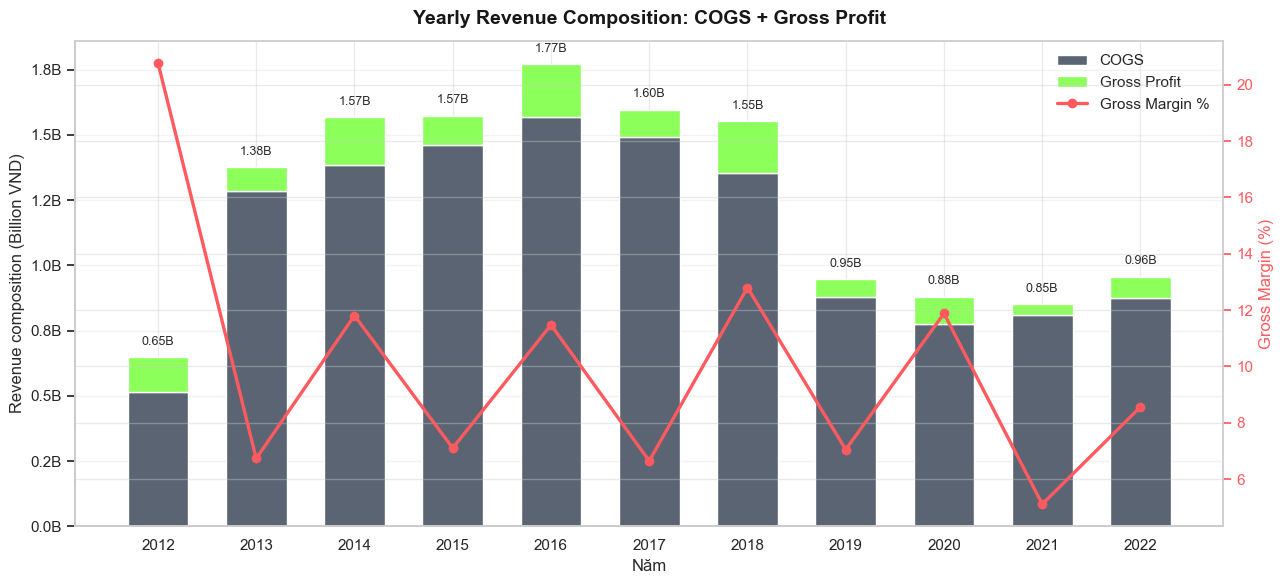

Năm revenue cao nhất: 2016 - 1,772,070,078
Năm gross profit cao nhất: 2016 - 203,354,561
Năm gross margin thấp nhất: 2021 - 5.11%
Năm có YoY revenue growth cao nhất: 2013 - 112.49%


In [239]:
year_positions = np.arange(len(yearly_business))

fig, ax1 = plt.subplots(figsize=(13, 6))
ax1.bar(
    year_positions,
    yearly_business['cogs'],
    color=PALETTE['base_bar'],
    width=0.62,
    label='COGS',
)
ax1.bar(
    year_positions,
    yearly_business['gross_profit'],
    bottom=yearly_business['cogs'],
    color=PALETTE['green'],
    width=0.62,
    label='Gross Profit',
)

clean_axis(ax1, xlabel='Năm', ylabel='Revenue composition (Billion VND)', title='Yearly Revenue Composition: COGS + Gross Profit')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(axis_billions))
ax1.set_xticks(year_positions)
ax1.set_xticklabels(yearly_business['year'].astype(int).astype(str))
ax1.grid(axis='y', alpha=0.25)

for idx, row in yearly_business.iterrows():
    ax1.text(
        idx,
        row['revenue'] + yearly_business['revenue'].max() * 0.02,
        format_billions(row['revenue']),
        ha='center',
        va='bottom',
        fontsize=9,
        color=PALETTE['dark_gray'],
    )

ax2 = ax1.twinx()
ax2.plot(
    year_positions,
    yearly_business['gross_margin'] * 100,
    color=PALETTE['risk_red'],
    linewidth=2.4,
    marker='o',
    label='Gross Margin %',
)
ax2.set_ylabel('Gross Margin (%)', color=PALETTE['risk_red'])
ax2.tick_params(axis='y', colors=PALETTE['risk_red'])

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, frameon=False, loc='upper right')
plt.tight_layout()
plt.show()

best_year_revenue = yearly_business.loc[yearly_business['revenue'].idxmax()]
best_year_gp = yearly_business.loc[yearly_business['gross_profit'].idxmax()]
lowest_year_margin = yearly_business.loc[yearly_business['gross_margin'].idxmin()]
best_yoy_growth = yearly_business.dropna(subset=['yoy_revenue_growth']).loc[
    yearly_business.dropna(subset=['yoy_revenue_growth'])['yoy_revenue_growth'].idxmax()
]

print('Năm revenue cao nhất:', int(best_year_revenue['year']), '-', format_currency(best_year_revenue['revenue']))
print('Năm gross profit cao nhất:', int(best_year_gp['year']), '-', format_currency(best_year_gp['gross_profit']))
print('Năm gross margin thấp nhất:', int(lowest_year_margin['year']), '-', format_pct(lowest_year_margin['gross_margin']))
print('Năm có YoY revenue growth cao nhất:', int(best_yoy_growth['year']), '-', format_pct(best_yoy_growth['yoy_revenue_growth']))


### 5. Mùa vụ đang đẩy tiền vào mạnh nhất ở tháng nào?

Sau khi đọc xong cấp năm, bước tiếp theo là nhìn seasonality. Chart này phải cho người xem thấy ngay tháng nào thường kéo revenue lên cao nhất và tháng nào thường đi kèm gross margin tốt hơn.


C:\Users\Admin\AppData\Local\Temp\ipykernel_25532\3514027904.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


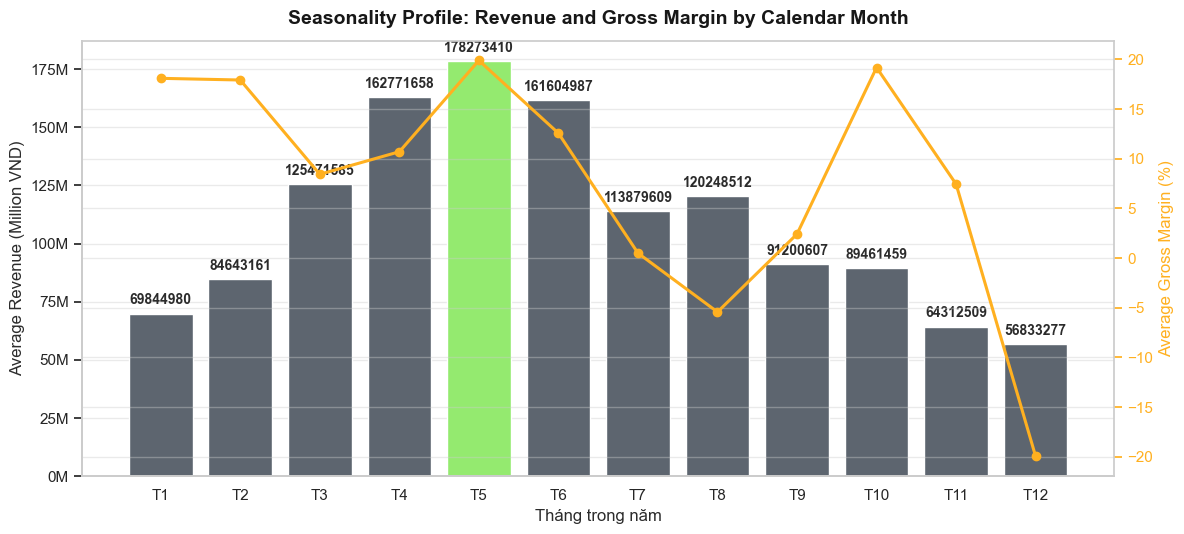

Top 3 tháng có average revenue cao nhất:


,month_label,avg_revenue,avg_gross_margin
4,T5,"178,273,410",19.90%
3,T4,"162,771,658",10.71%
5,T6,"161,604,987",12.57%


Bottom 3 tháng có average revenue thấp nhất:


,month_label,avg_revenue,avg_gross_margin
11,T12,"56,833,277",-19.97%
10,T11,"64,312,509",7.45%
0,T1,"69,844,980",18.10%


In [240]:
best_calendar_month = calendar_month_profile.loc[calendar_month_profile['avg_revenue'].idxmax(), 'month']
bar_colors = [
    PALETTE['green'] if month == best_calendar_month else PALETTE['base_bar']
    for month in calendar_month_profile['month']
]

fig, ax1 = plt.subplots(figsize=(12, 5.5))
sns.barplot(
    data=calendar_month_profile,
    x='month_label',
    y='avg_revenue',
    palette=bar_colors,
    ax=ax1,
)
clean_axis(ax1, xlabel='Tháng trong năm', ylabel='Average Revenue (Million VND)', title='Seasonality Profile: Revenue and Gross Margin by Calendar Month')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(axis_millions))
add_bar_labels(ax1, fmt='{:.0f}')

ax2 = ax1.twinx()
ax2.plot(
    np.arange(len(calendar_month_profile)),
    calendar_month_profile['avg_gross_margin'] * 100,
    color=PALETTE['warning'],
    linewidth=2.2,
    marker='o',
)
ax2.set_ylabel('Average Gross Margin (%)', color=PALETTE['warning'])
ax2.tick_params(axis='y', colors=PALETTE['warning'])

plt.tight_layout()
plt.show()

top_3_months = calendar_month_profile.nlargest(3, 'avg_revenue')[['month_label', 'avg_revenue', 'avg_gross_margin']].copy()
bottom_3_months = calendar_month_profile.nsmallest(3, 'avg_revenue')[['month_label', 'avg_revenue', 'avg_gross_margin']].copy()

print('Top 3 tháng có average revenue cao nhất:')
display(
    top_3_months.assign(
        avg_revenue=top_3_months['avg_revenue'].map(format_currency),
        avg_gross_margin=top_3_months['avg_gross_margin'].map(format_pct),
    )
)

print('Bottom 3 tháng có average revenue thấp nhất:')
display(
    bottom_3_months.assign(
        avg_revenue=bottom_3_months['avg_revenue'].map(format_currency),
        avg_gross_margin=bottom_3_months['avg_gross_margin'].map(format_pct),
    )
)


### 6. Peak month có lặp lại ổn định qua các năm không?

Heatmap giúp trả lời xem seasonality vừa thấy ở trên có thực sự lặp lại qua từng năm hay chỉ là hiệu ứng cộng dồn. Đây là chart nên giữ vì rất trực diện khi cần nhìn tháng đậm - tháng nhạt trong 11 năm.


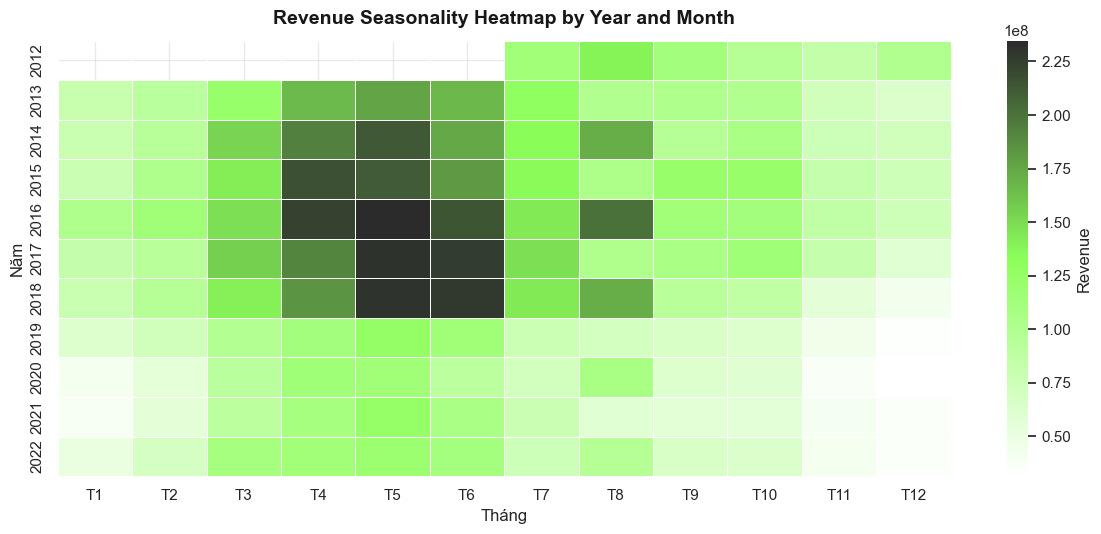

Tháng peak revenue của từng năm:


,year,month,month_label,revenue
1,2012,8,T8,"138,830,457"
10,2013,5,T5,"175,955,383"
22,2014,5,T5,"213,211,703"
33,2015,4,T4,"216,298,818"
46,2016,5,T5,"234,713,226"
58,2017,5,T5,"231,107,218"
70,2018,5,T5,"230,162,011"
82,2019,5,T5,"126,790,092"
93,2020,4,T4,"115,766,274"
106,2021,5,T5,"124,394,750"


Tháng xuất hiện nhiều nhất trong nhóm peak month: T5


In [241]:
seasonality_heatmap = monthly_business.pivot_table(index='year', columns='month', values='revenue', aggfunc='sum')
seasonality_heatmap = seasonality_heatmap.reindex(columns=range(1, 13))

fig, ax = plt.subplots(figsize=(12, 5.5))
sns.heatmap(
    seasonality_heatmap,
    cmap=sns.blend_palette([PALETTE['white'], PALETTE['green'], PALETTE['dark_gray']], as_cmap=True),
    linewidths=0.5,
    linecolor=PALETTE['white'],
    cbar_kws={'label': 'Revenue'},
    ax=ax,
)
ax.set_title('Revenue Seasonality Heatmap by Year and Month', fontsize=14, fontweight='bold', color=PALETTE['black'], pad=12)
ax.set_xlabel('Tháng')
ax.set_ylabel('Năm')
ax.set_xticklabels([f'T{i}' for i in range(1, 13)], rotation=0)
plt.tight_layout()
plt.show()

most_common_peak_month = peak_month_by_year['month_label'].mode().iat[0]

print('Tháng peak revenue của từng năm:')
display(peak_month_by_year.assign(revenue=peak_month_by_year['revenue'].map(format_currency)))
print('Tháng xuất hiện nhiều nhất trong nhóm peak month:', most_common_peak_month)


### 7. Dòng tiền tích lũy tăng đều hay gãy nhịp?

Nếu người xem chỉ nhìn từng tháng riêng lẻ thì khá rối. Cumulative chart cho phép thấy rất nhanh giai đoạn nào doanh nghiệp tăng tiền đều, giai đoạn nào đi ngang và giai đoạn nào gross profit bị tích lũy chậm lại.


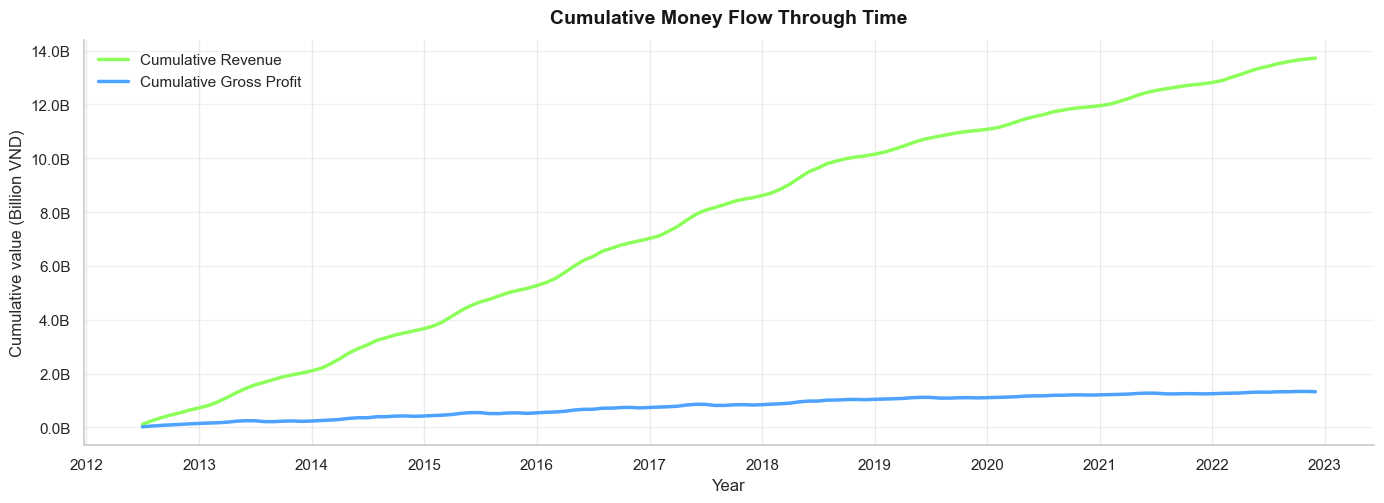

In [242]:
cumulative_plot = monthly_business[['year_month', 'cumulative_revenue', 'cumulative_gross_profit']].copy()
cumulative_plot_long = cumulative_plot.melt(
    id_vars='year_month',
    value_vars=['cumulative_revenue', 'cumulative_gross_profit'],
    var_name='Metric',
    value_name='Value',
)
cumulative_plot_long['Metric'] = cumulative_plot_long['Metric'].map(
    {
        'cumulative_revenue': 'Cumulative Revenue',
        'cumulative_gross_profit': 'Cumulative Gross Profit',
    }
)

fig, ax = plt.subplots(figsize=(14, 5.2))
sns.lineplot(
    data=cumulative_plot_long,
    x='year_month',
    y='Value',
    hue='Metric',
    linewidth=2.5,
    palette={
        'Cumulative Revenue': PALETTE['green'],
        'Cumulative Gross Profit': PALETTE['info_blue'],
    },
    ax=ax,
)

clean_axis(ax, xlabel='Year', ylabel='Cumulative value (Billion VND)', title='Cumulative Money Flow Through Time')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(axis_billions))
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(axis='y', alpha=0.25)
ax.legend(title='', frameon=False, loc='upper left')
plt.tight_layout()
plt.show()


In [243]:
best_revenue_month = monthly_business.loc[monthly_business['revenue'].idxmax()]
best_gp_month = monthly_business.loc[monthly_business['gross_profit'].idxmax()]
lowest_revenue_month = monthly_business.loc[monthly_business['revenue'].idxmin()]
lowest_gp_month = monthly_business.loc[monthly_business['gross_profit'].idxmin()]

print('Tháng revenue cao nhất:', format_period(best_revenue_month['year_month']), '-', format_currency(best_revenue_month['revenue']))
print('Tháng revenue thấp nhất:', format_period(lowest_revenue_month['year_month']), '-', format_currency(lowest_revenue_month['revenue']))
print('Tháng gross profit cao nhất:', format_period(best_gp_month['year_month']), '-', format_currency(best_gp_month['gross_profit']))
print('Tháng gross profit thấp nhất:', format_period(lowest_gp_month['year_month']), '-', format_currency(lowest_gp_month['gross_profit']))
print('Cumulative revenue cuối kỳ:', format_currency(monthly_business['cumulative_revenue'].iloc[-1]))
print('Cumulative gross profit cuối kỳ:', format_currency(monthly_business['cumulative_gross_profit'].iloc[-1]))


Tháng revenue cao nhất: 2016-05 - 234,713,226
Tháng revenue thấp nhất: 2020-12 - 31,346,459
Tháng gross profit cao nhất: 2018-05 - 47,580,366
Tháng gross profit thấp nhất: 2017-08 - -37,756,525
Cumulative revenue cuối kỳ: 13,721,393,513
Cumulative gross profit cuối kỳ: 1,329,216,858


### 8. Có tháng nào revenue tăng nhưng giữ lại ít tiền hơn không?

Đây là chart chẩn đoán để bắt các tháng doanh thu đi lên nhưng gross margin lại co lại. Nếu có nhiều điểm nằm ở góc phải - dưới, tăng trưởng đang đổi lấy chất lượng lợi nhuận.


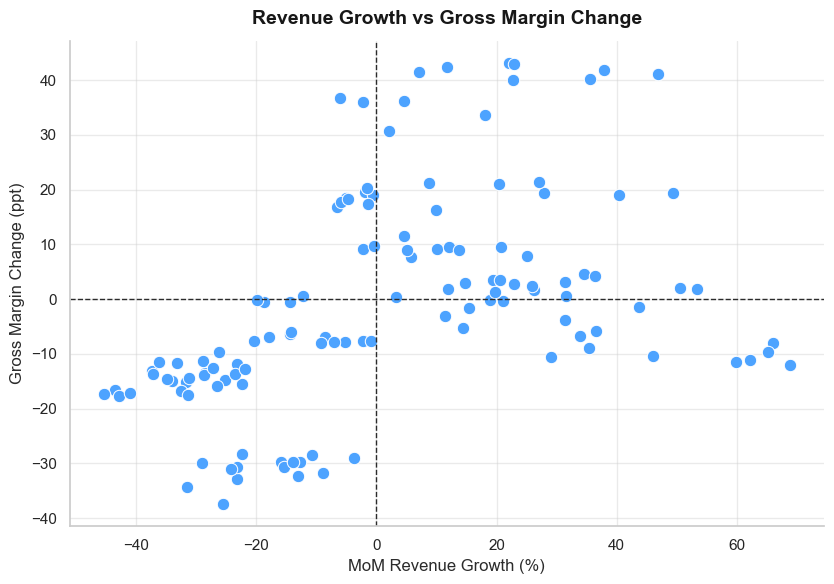

Số tháng revenue tăng nhưng gross margin giảm: 17
Top 10 tháng revenue tăng nhưng gross margin giảm mạnh:


,year_month,revenue,gross_margin,mom_revenue_growth,margin_change
0,2020-03,"91,948,444",8.52%,68.81%,-12.10%
1,2017-03,"155,848,665",7.44%,66.07%,-8.02%
2,2021-03,"91,376,025",8.33%,65.18%,-9.69%
3,2014-03,"153,448,662",9.32%,62.27%,-11.06%
4,2022-03,"110,665,547",6.17%,59.90%,-11.55%
5,2018-03,"140,016,604",9.73%,46.13%,-10.44%
6,2021-02,"55,317,624",18.02%,43.68%,-1.38%
7,2015-03,"140,986,602",9.65%,36.59%,-5.92%
8,2019-03,"98,590,498",8.44%,35.44%,-8.89%
9,2013-03,"123,582,754",8.19%,33.91%,-6.75%


In [244]:
scatter_data = monthly_business.dropna(subset=['mom_revenue_growth', 'margin_change']).copy()

fig, ax = plt.subplots(figsize=(8.5, 6))
sns.scatterplot(
    data=scatter_data,
    x=scatter_data['mom_revenue_growth'] * 100,
    y=scatter_data['margin_change'] * 100,
    s=80,
    color=PALETTE['info_blue'],
    ax=ax,
)
ax.axhline(0, color=PALETTE['dark_gray'], linestyle='--', linewidth=1)
ax.axvline(0, color=PALETTE['dark_gray'], linestyle='--', linewidth=1)
clean_axis(ax, xlabel='MoM Revenue Growth (%)', ylabel='Gross Margin Change (ppt)', title='Revenue Growth vs Gross Margin Change')
plt.tight_layout()
plt.show()

top_margin_pressure_months = margin_pressure_months.loc[
    :, ['year_month', 'revenue', 'gross_margin', 'mom_revenue_growth', 'margin_change']
].head(10).copy()

print('Số tháng revenue tăng nhưng gross margin giảm:', len(margin_pressure_months))
if top_margin_pressure_months.empty:
    print('Không có tháng nào thỏa điều kiện revenue tăng nhưng gross margin giảm.')
else:
    print('Top 10 tháng revenue tăng nhưng gross margin giảm mạnh:')
    display(
        top_margin_pressure_months.assign(
            year_month=top_margin_pressure_months['year_month'].map(format_period),
            revenue=top_margin_pressure_months['revenue'].map(format_currency),
            gross_margin=top_margin_pressure_months['gross_margin'].map(format_pct),
            mom_revenue_growth=top_margin_pressure_months['mom_revenue_growth'].map(format_pct),
            margin_change=top_margin_pressure_months['margin_change'].map(format_pct),
        )
    )


### 9. Refund đang kéo ngược lại bao nhiêu tiền?

Revenue chính vẫn nên giữ theo thời điểm order, nhưng người xem vẫn cần một chart riêng để thấy phần tiền bị kéo ngược lại bởi refund đang xuất hiện ở đâu và nặng đến mức nào.


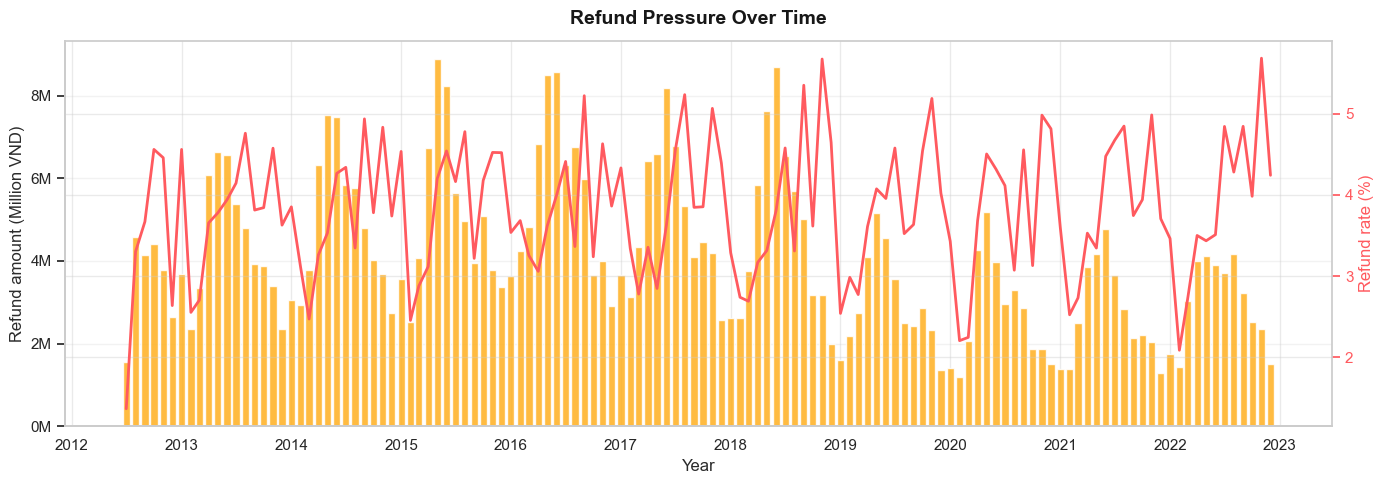

Total refund amount: 510,598,507
Refund rate indicator: 3.72%
Top refund months:


,year_month,total_refund_amount,refund_rate
34,2015-05,"8,884,003",4.20%
71,2018-06,"8,685,478",3.81%
47,2016-06,"8,577,972",4.00%
46,2016-05,"8,495,853",3.62%
35,2015-06,"8,224,575",4.54%


In [245]:
returns_eda = returns.copy()
returns_eda['return_month'] = returns_eda['return_date'].dt.to_period('M').dt.to_timestamp()

monthly_refunds = (
    returns_eda.groupby('return_month', as_index=False)['refund_amount']
    .sum()
    .rename(columns={'return_month': 'year_month', 'refund_amount': 'total_refund_amount'})
)
refund_indicator = monthly_business[['year_month', 'revenue']].merge(monthly_refunds, on='year_month', how='left')
refund_indicator['total_refund_amount'] = refund_indicator['total_refund_amount'].fillna(0)
refund_indicator['refund_rate'] = refund_indicator['total_refund_amount'] / refund_indicator['revenue'].replace(0, np.nan)

total_refund_amount = refund_indicator['total_refund_amount'].sum()
overall_refund_rate = total_refund_amount / monthly_business['revenue'].sum()
top_refund_months = refund_indicator.nlargest(5, 'total_refund_amount')[
    ['year_month', 'total_refund_amount', 'refund_rate']
].copy()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.bar(
    refund_indicator['year_month'],
    refund_indicator['total_refund_amount'],
    color=PALETTE['warning'],
    width=24,
    alpha=0.85,
)
clean_axis(ax1, xlabel='Year', ylabel='Refund amount (Million VND)', title='Refund Pressure Over Time')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(axis_millions))
ax1.xaxis.set_major_locator(mdates.YearLocator(1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.grid(axis='y', alpha=0.25)

ax2 = ax1.twinx()
ax2.plot(
    refund_indicator['year_month'],
    refund_indicator['refund_rate'] * 100,
    color=PALETTE['risk_red'],
    linewidth=2,
)
ax2.set_ylabel('Refund rate (%)', color=PALETTE['risk_red'])
ax2.tick_params(axis='y', colors=PALETTE['risk_red'])

plt.tight_layout()
plt.show()

print('Total refund amount:', format_currency(total_refund_amount))
print('Refund rate indicator:', format_pct(overall_refund_rate))
print('Top refund months:')
display(
    top_refund_months.assign(
        year_month=top_refund_months['year_month'].map(format_period),
        total_refund_amount=top_refund_months['total_refund_amount'].map(format_currency),
        refund_rate=top_refund_months['refund_rate'].map(format_pct),
    )
)
